# 02 - Explorative Datenanalyse: Forex-Daten (EODHD API)

**Ziel:** Forex-Kursdaten von EODHD laden, erkunden und erste Qualitaetspruefung durchfuehren.

**Waehrungspaare:** EUR/USD, EUR/CHF, GBP/USD

**Datenquelle:** EODHD API (https://eodhd.com)

**API-Dokumentation:** https://eodhd.com/financial-apis/api-for-historical-data-and-volumes

---

## 1. Setup und Imports

In [2]:
# Bibliotheken importieren
import requests              # HTTP-Anfragen an die API
import pandas as pd          # Datenverarbeitung
import numpy as np           # Numerische Berechnungen
import matplotlib.pyplot as plt  # Visualisierung
import seaborn as sns        # Erweiterte Visualisierung
import os                    # Dateipfade
from dotenv import load_dotenv  # API-Key aus .env laden

# Darstellung konfigurieren
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print('Setup erfolgreich!')

Setup erfolgreich!


## 2. API-Key laden

Der API-Key wird aus der `.env` Datei geladen (wird nicht ins Git hochgeladen).

In [3]:
# .env Datei laden - verschiedene Pfade testen
import pathlib

for env_path in ['../.env', '.env', str(pathlib.Path.home() / 'Documents/GitHub/datawrangling/.env')]:
    if os.path.exists(env_path):
        load_dotenv(dotenv_path=env_path, override=True)
        print(f'.env gefunden unter: {env_path}')
        break

# API-Key auslesen
api_key = os.getenv('EODHD_API_KEY')

if api_key and api_key != 'dein_api_key_hier':
    print(f'API-Key geladen (beginnt mit: {api_key[:4]}...)')
else:
    print('FEHLER: Kein API-Key gefunden!')
    print(f'Aktuelles Verzeichnis: {os.getcwd()}')

.env gefunden unter: ../.env
API-Key geladen (beginnt mit: 6917...)


## 3. Daten laden von EODHD API

Die EODHD API liefert Forex-Daten im Format:

`https://eodhd.com/api/eod/EURUSD.FOREX?from=2024-01-01&to=2025-12-31&period=d&api_token=KEY&fmt=json`

Die Antwort ist ein JSON-Array mit: date, open, high, low, close, adjusted_close, volume

In [4]:
# Konfiguration: Waehrungspaare und Zeitraum (gleich wie Yahoo Finance!)
CURRENCY_PAIRS = {
    'EURUSD.FOREX': 'EUR/USD',
    'EURCHF.FOREX': 'EUR/CHF',
    'GBPUSD.FOREX': 'GBP/USD',
}

START_DATE = '2024-01-01'
END_DATE = '2025-12-31'

print(f'Zeitraum: {START_DATE} bis {END_DATE}')
print(f'Waehrungspaare: {list(CURRENCY_PAIRS.values())}')

Zeitraum: 2024-01-01 bis 2025-12-31
Waehrungspaare: ['EUR/USD', 'EUR/CHF', 'GBP/USD']


In [5]:
# Daten von der EODHD API laden
forex_data = {}

for eodhd_symbol, pair_name in CURRENCY_PAIRS.items():
    print(f'Lade {pair_name} ({eodhd_symbol})...')
    
    # API-URL und Parameter zusammenbauen
    url = f'https://eodhd.com/api/eod/{eodhd_symbol}'
    params = {
        'from': START_DATE,
        'to': END_DATE,
        'period': 'd',
        'api_token': api_key,
        'fmt': 'json'
    }
    
    # HTTP-GET Request ausfuehren
    response = requests.get(url, params=params)
    
    # Status pruefen
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        forex_data[pair_name] = df
        print(f'  -> {len(df)} Zeilen geladen')
    else:
        print(f'  -> FEHLER: HTTP {response.status_code}')

print('\nAlle Daten geladen!')

Lade EUR/USD (EURUSD.FOREX)...
  -> 677 Zeilen geladen
Lade EUR/CHF (EURCHF.FOREX)...
  -> 559 Zeilen geladen
Lade GBP/USD (GBPUSD.FOREX)...
  -> 681 Zeilen geladen

Alle Daten geladen!


## 4. Erste Datenuebersich

In [6]:
# Uebersicht fuer jedes Waehrungspaar
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    print(f'Shape (Zeilen x Spalten): {df.shape}')
    print(f'Zeitraum: {df.index.min()} bis {df.index.max()}')
    print(f'Spalten: {list(df.columns)}')
    print(f'Datentypen:\n{df.dtypes}')
    print(f'\nErste 3 Zeilen:')
    display(df.head(3))


EUR/USD
Shape (Zeilen x Spalten): (677, 6)
Zeitraum: 2024-01-01 00:00:00 bis 2025-12-31 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2024-01-01,1.1046,1.1046,1.1036,1.1037,1.1037,112
2024-01-02,1.1037,1.1043,1.0939,1.0942,1.0942,909
2024-01-03,1.0942,1.0966,1.0893,1.0926,1.0926,465



EUR/CHF
Shape (Zeilen x Spalten): (559, 6)
Zeitraum: 2024-01-01 00:00:00 bis 2025-12-31 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2024-01-01,0.9284,0.9601,0.9275,0.9284,0.9284,0
2024-01-02,0.9292,0.9339,0.9282,0.9292,0.9292,0
2024-01-03,0.9302,0.9339,0.9291,0.9302,0.9302,0



GBP/USD
Shape (Zeilen x Spalten): (681, 6)
Zeitraum: 2024-01-01 00:00:00 bis 2025-12-31 00:00:00
Spalten: ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
Datentypen:
open              float64
high              float64
low               float64
close             float64
adjusted_close    float64
volume              int64
dtype: object

Erste 3 Zeilen:


,open,high,low,close,adjusted_close,volume
date,,,,,,
2024-01-01,1.2728,1.2735,1.2721,1.2728,1.2728,74
2024-01-02,1.2728,1.2760,1.2611,1.2623,1.2623,936
2024-01-03,1.2623,1.2677,1.2616,1.2673,1.2673,73


## 5. Datenqualitaetspruefung

In [7]:
# Fehlende Werte pruefen
print('FEHLENDE WERTE PRO WAEHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    
    print(f'\n{pair_name}:')
    if missing.sum() == 0:
        print('  Keine fehlenden Werte!')
    else:
        for col in df.columns:
            if missing[col] > 0:
                print(f'  {col}: {missing[col]} fehlend ({missing_pct[col]}%)')

FEHLENDE WERTE PRO WAEHRUNGSPAAR

EUR/USD:
  Keine fehlenden Werte!

EUR/CHF:
  Keine fehlenden Werte!

GBP/USD:
  Keine fehlenden Werte!


In [8]:
# Duplikate pruefen
print('DUPLIKATE PRO WAEHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    dupes = df.index.duplicated().sum()
    print(f'{pair_name}: {dupes} Duplikate')

DUPLIKATE PRO WAEHRUNGSPAAR
EUR/USD: 0 Duplikate
EUR/CHF: 0 Duplikate
GBP/USD: 0 Duplikate


In [9]:
# Deskriptive Statistik
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'Deskriptive Statistik: {pair_name}')
    print(f'{"=" * 50}')
    display(df.describe())


Deskriptive Statistik: EUR/USD


,open,high,low,close,adjusted_close,volume
count,677.000000,677.000000,677.000000,677.000000,677.000000,6.770000e+02
mean,1.107674,1.110987,1.104594,1.107771,1.107771,7.435257e+06
std,0.045121,0.044667,0.045615,0.045197,0.045197,9.611896e+06
min,1.024300,1.024500,1.012500,1.024300,1.024300,2.000000e+01
25%,1.077600,1.080300,1.074800,1.077800,1.077800,2.280000e+02
50%,1.093700,1.095500,1.090400,1.093700,1.093700,7.076000e+03
75%,1.156600,1.159700,1.154100,1.156700,1.156700,1.733025e+07
max,1.187100,1.191800,1.180800,1.187100,1.187100,3.361569e+07



Deskriptive Statistik: EUR/CHF


,open,high,low,close,adjusted_close,volume
count,559.000000,559.000000,559.000000,559.000000,559.000000,559.0
mean,0.943917,0.945986,0.941866,0.943946,0.943946,0.0
std,0.015561,0.015641,0.015404,0.015534,0.015534,0.0
min,0.922300,0.922400,0.917500,0.922300,0.922300,0.0
25%,0.933400,0.935400,0.931600,0.933600,0.933600,0.0
50%,0.938600,0.940600,0.936400,0.938600,0.938600,0.0
75%,0.950900,0.953950,0.948900,0.950900,0.950900,0.0
max,0.991900,0.993000,0.991600,0.991900,0.991900,0.0



Deskriptive Statistik: GBP/USD


,open,high,low,close,adjusted_close,volume
count,681.000000,681.000000,681.000000,681.000000,681.000000,6.810000e+02
mean,1.299723,1.303116,1.296311,1.299820,1.299820,8.533122e+06
std,0.038207,0.038133,0.038322,0.038246,0.038246,1.124891e+07
min,1.216300,1.216500,1.210000,1.216300,1.216300,2.000000e+01
25%,1.267700,1.270500,1.263300,1.267700,1.267700,2.310000e+02
50%,1.295800,1.299500,1.293200,1.295800,1.295800,3.446000e+03
75%,1.335800,1.339200,1.331700,1.335900,1.335900,1.920050e+07
max,1.374600,1.378900,1.371400,1.374600,1.374600,4.134986e+07


## 6. Visualisierung

### 6.1 Kursverlauf (Close-Preis)

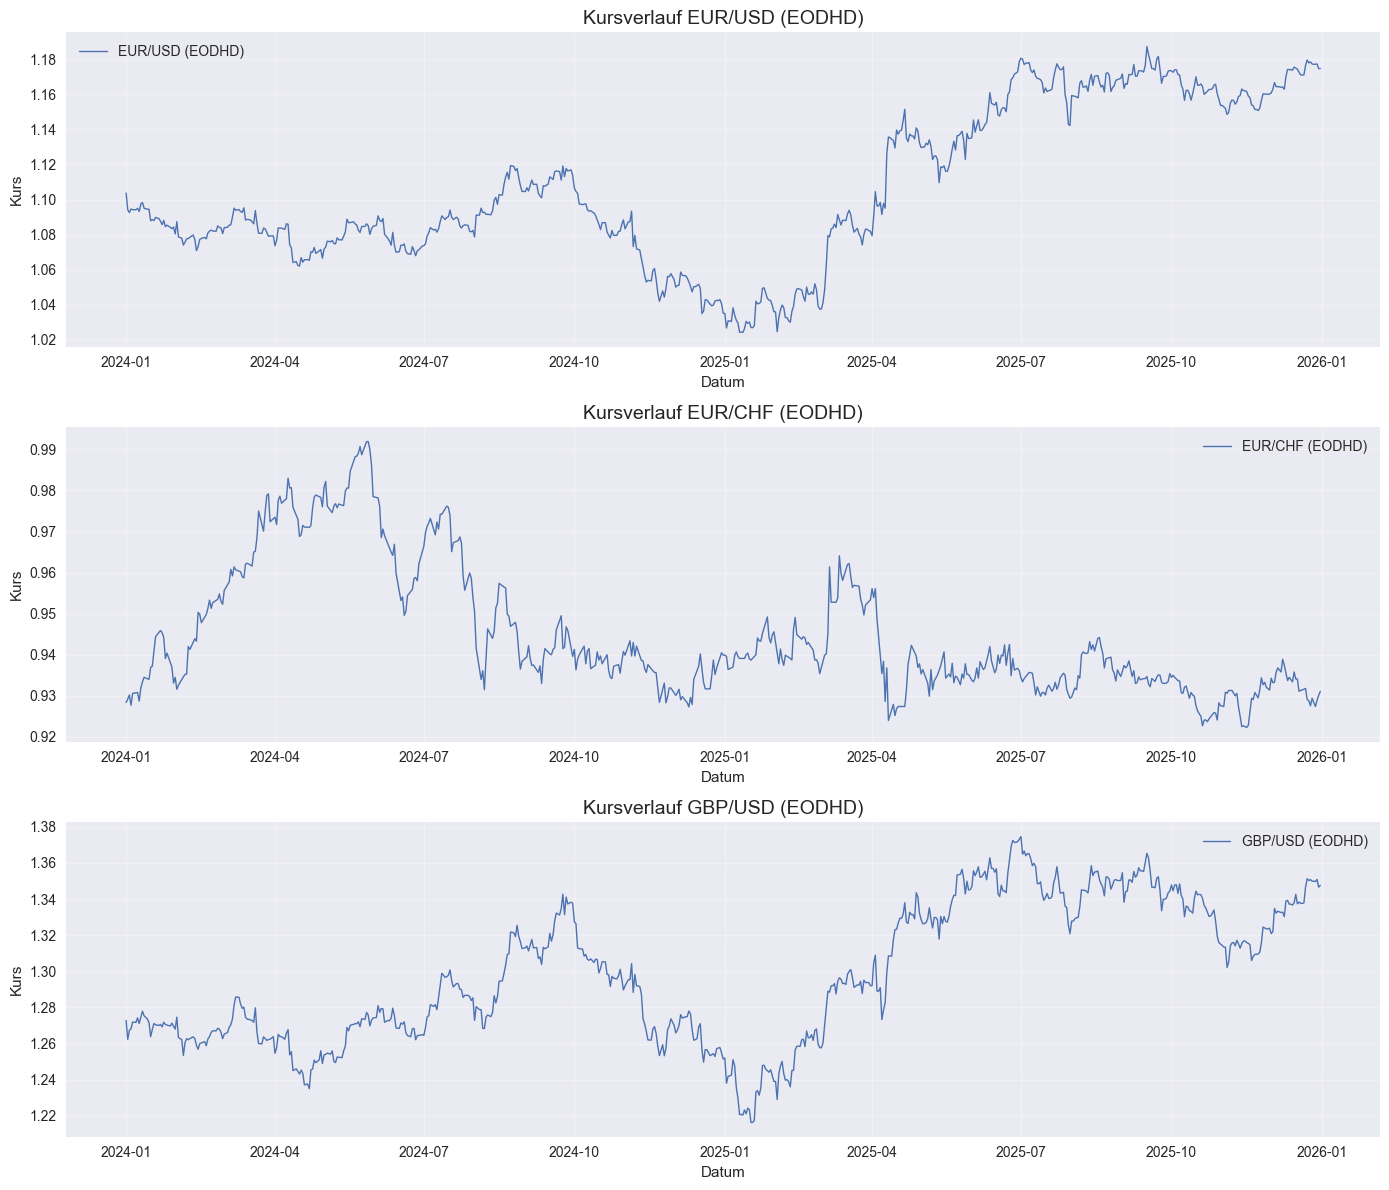

In [10]:
# Kursverlauf plotten
fig, axes = plt.subplots(len(forex_data), 1, figsize=(14, 4 * len(forex_data)))

if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    ax.plot(df.index, df['close'], label=f'{pair_name} (EODHD)', linewidth=1)
    ax.set_title(f'Kursverlauf {pair_name} (EODHD)', fontsize=14)
    ax.set_xlabel('Datum')
    ax.set_ylabel('Kurs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Verteilung der taeglichen Renditen

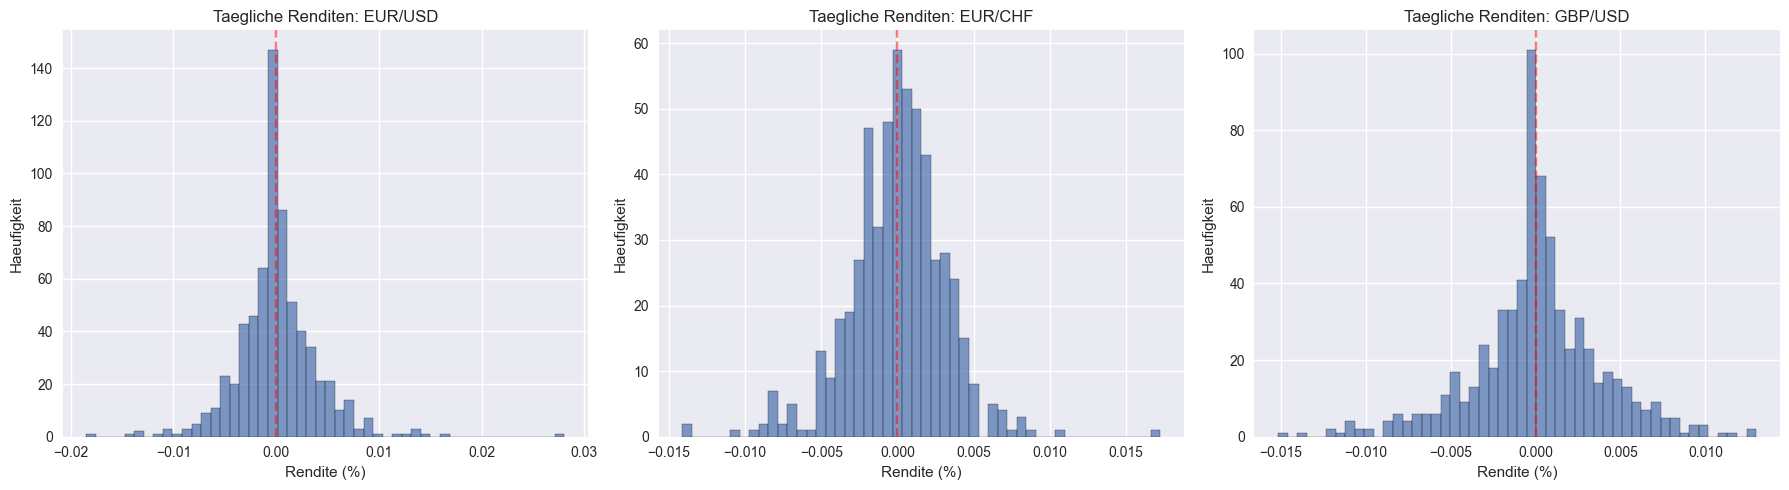

In [11]:
# Taegliche Renditen
fig, axes = plt.subplots(1, len(forex_data), figsize=(6 * len(forex_data), 5))

if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    returns = df['close'].pct_change().dropna()
    ax.hist(returns, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Taegliche Renditen: {pair_name}', fontsize=12)
    ax.set_xlabel('Rendite (%)')
    ax.set_ylabel('Haeufigkeit')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 6.3 Fehlende Tage identifizieren

In [12]:
# Alle fehlenden Tage anzeigen
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    
    all_days = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    missing_days = all_days.difference(df.index)
    missing_weekends = [d for d in missing_days if d.weekday() >= 5]
    missing_weekdays = [d for d in missing_days if d.weekday() < 5]
    
    print(f'Gesamte fehlende Tage:     {len(missing_days)}')
    print(f'  davon Wochenenden:       {len(missing_weekends)}')
    print(f'  davon Wochentage:        {len(missing_weekdays)}')
    
    if len(missing_weekdays) > 0:
        print(f'\n  Fehlende Wochentage (Feiertage etc.):')
        for d in missing_weekdays:
            day_name = ['Mo', 'Di', 'Mi', 'Do', 'Fr'][d.weekday()]
            print(f'    {d.strftime("%Y-%m-%d")} ({day_name})')


EUR/USD
Gesamte fehlende Tage:     54
  davon Wochenenden:       54
  davon Wochentage:        0

EUR/CHF
Gesamte fehlende Tage:     172
  davon Wochenenden:       172
  davon Wochentage:        0

GBP/USD
Gesamte fehlende Tage:     50
  davon Wochenenden:       50
  davon Wochentage:        0


## 7. Rohdaten speichern

In [13]:
# Rohdaten als CSV speichern
OUTPUT_DIR = '../data/raw/forex/eodhd'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for pair_name, df in forex_data.items():
    safe_name = pair_name.replace('/', '_')
    filename = f'{safe_name}_{START_DATE}_to_{END_DATE}.csv'
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath)
    print(f'Gespeichert: {filepath} ({len(df)} Zeilen)')

print('\nAlle Rohdaten gespeichert!')

Gespeichert: ../data/raw/forex/eodhd/EUR_USD_2024-01-01_to_2025-12-31.csv (677 Zeilen)
Gespeichert: ../data/raw/forex/eodhd/EUR_CHF_2024-01-01_to_2025-12-31.csv (559 Zeilen)
Gespeichert: ../data/raw/forex/eodhd/GBP_USD_2024-01-01_to_2025-12-31.csv (681 Zeilen)

Alle Rohdaten gespeichert!


## 8. Zusammenfassung

### Erkenntnisse aus der EDA:
- **Datenumfang:** (hier Ergebnisse eintragen nach Ausfuehrung)
- **Fehlende Werte:** (hier Ergebnisse eintragen)
- **Duplikate:** (hier Ergebnisse eintragen)
- **Auffaelligkeiten:** (hier Ergebnisse eintragen)

### Naechste Schritte:
1. Datenqualitaet zwischen Yahoo und EODHD vergleichen
2. Daten bereinigen und harmonisieren
3. Nachrichten laden (EODHD News API + Webscraping)